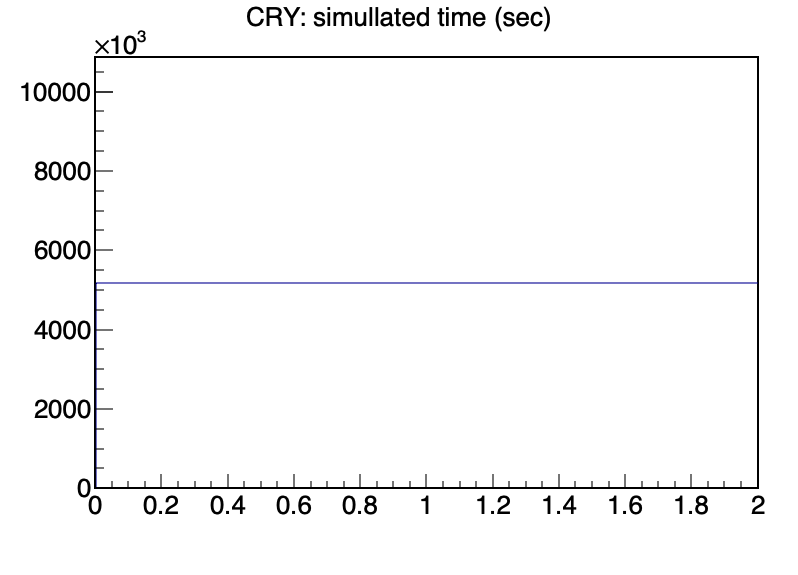

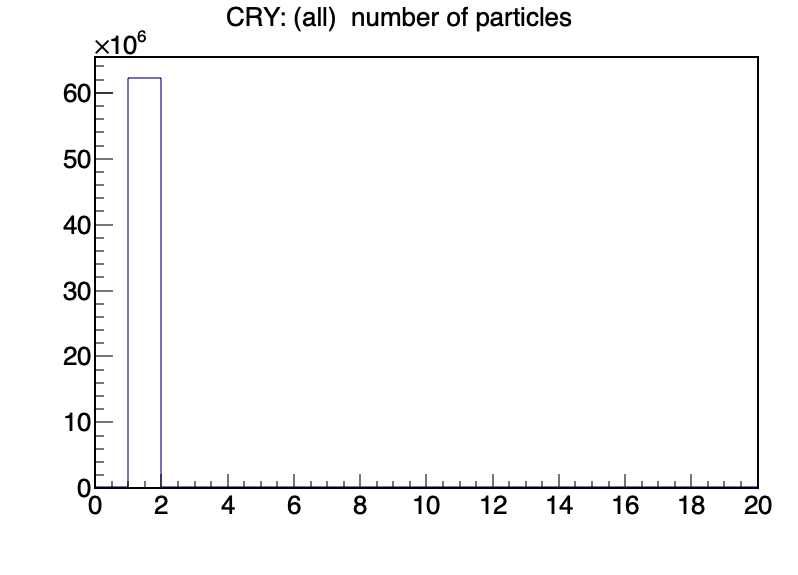

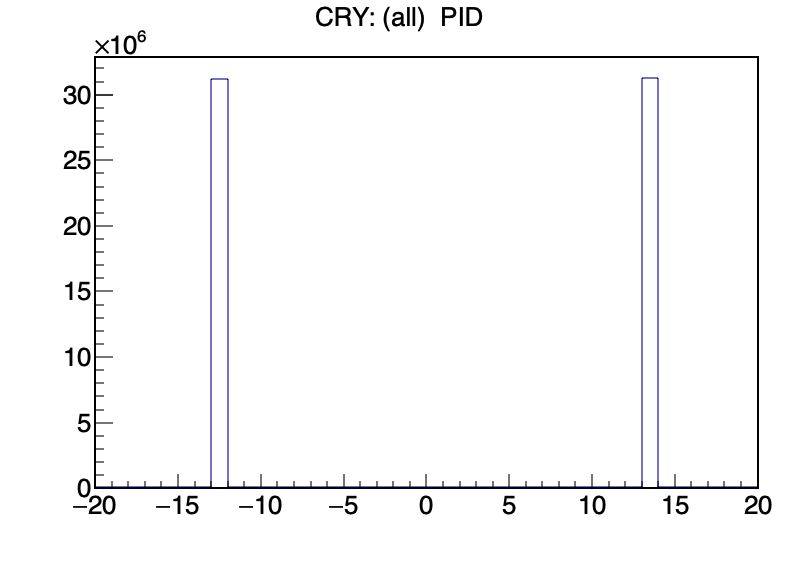

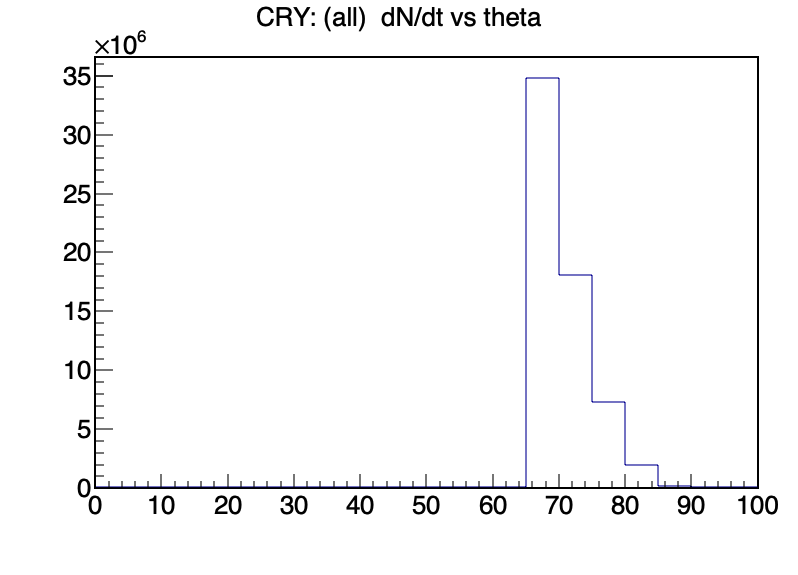

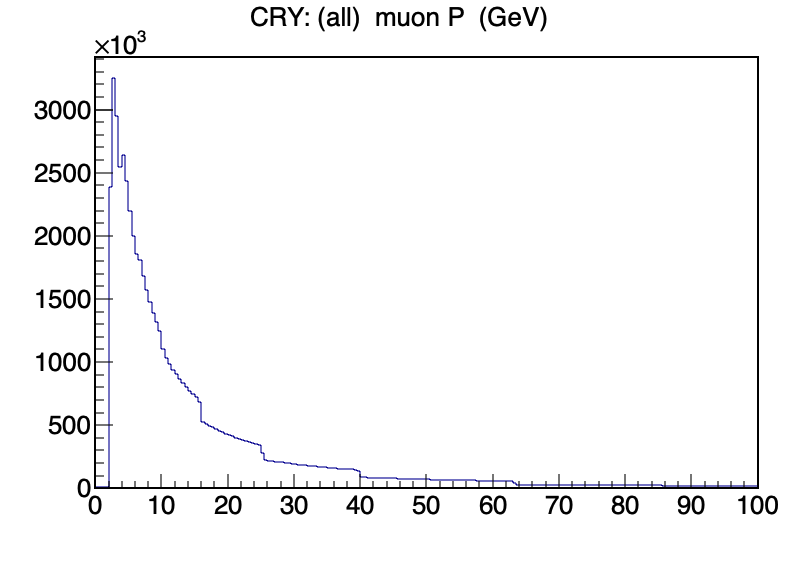

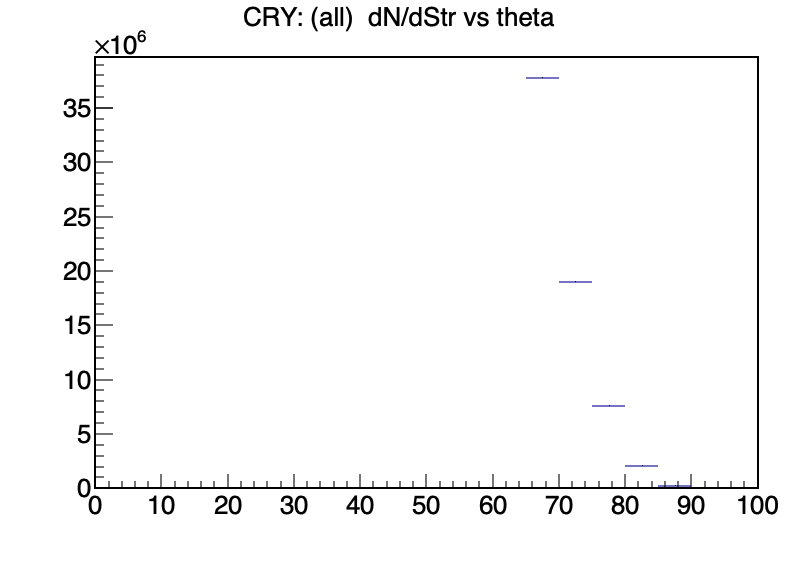

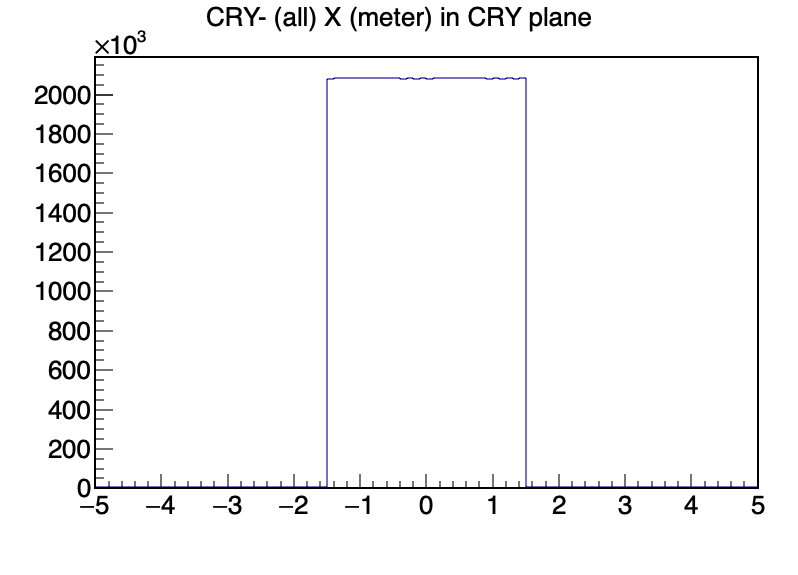

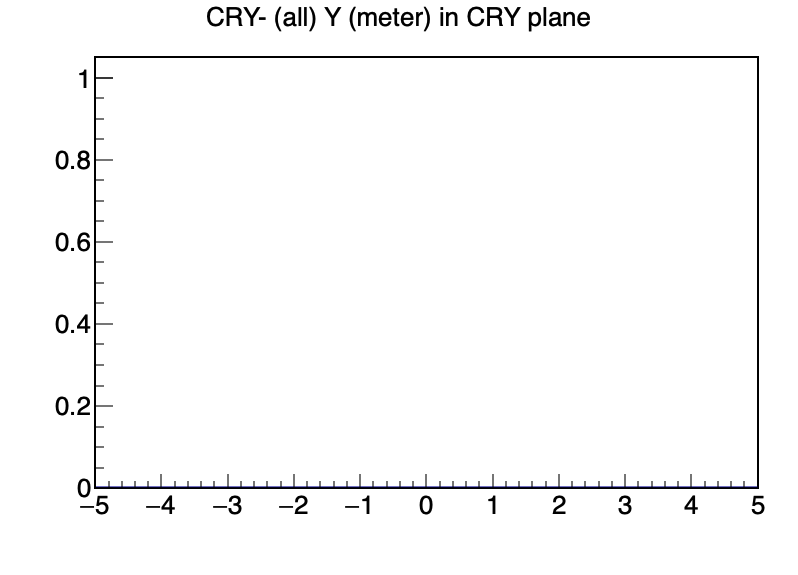

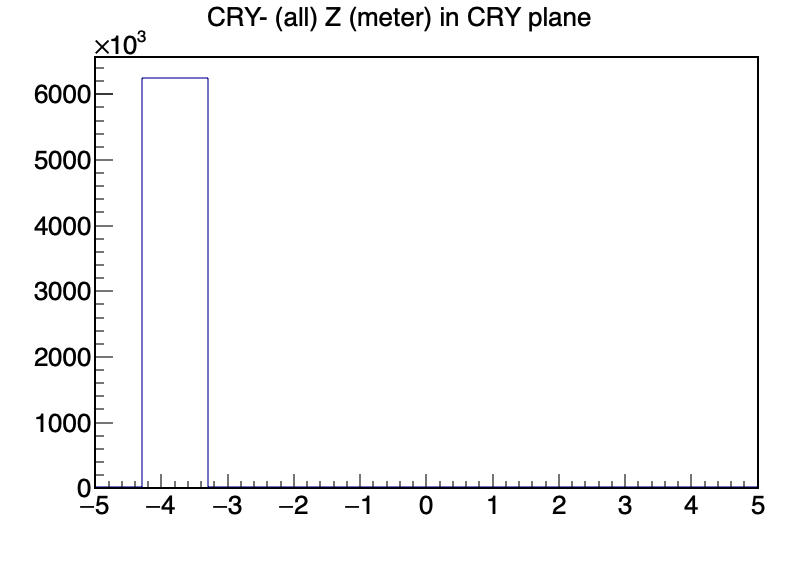

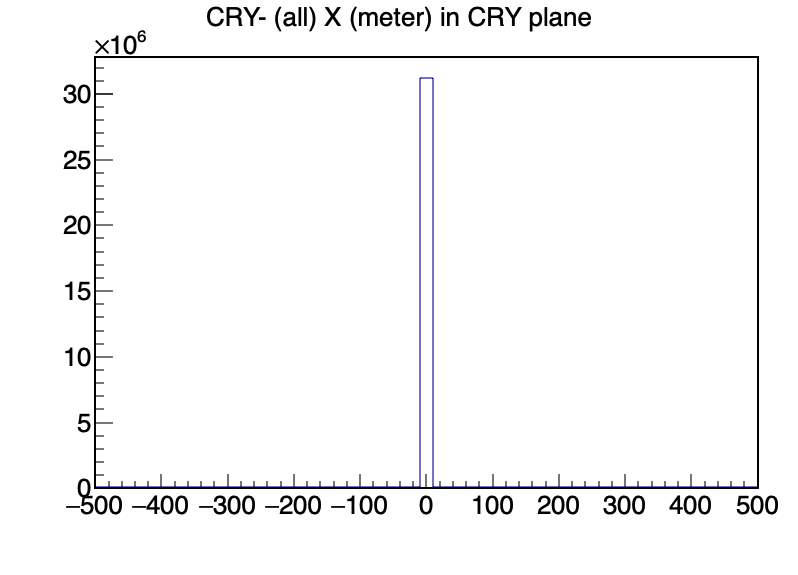

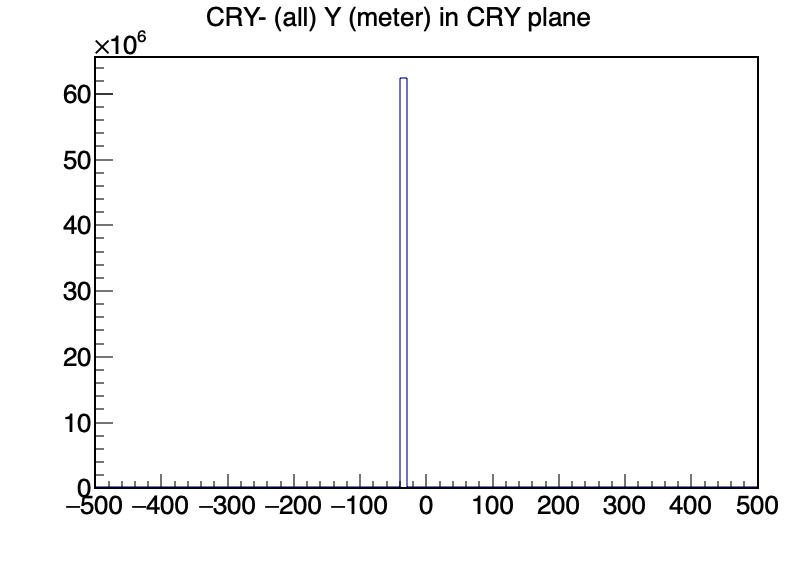

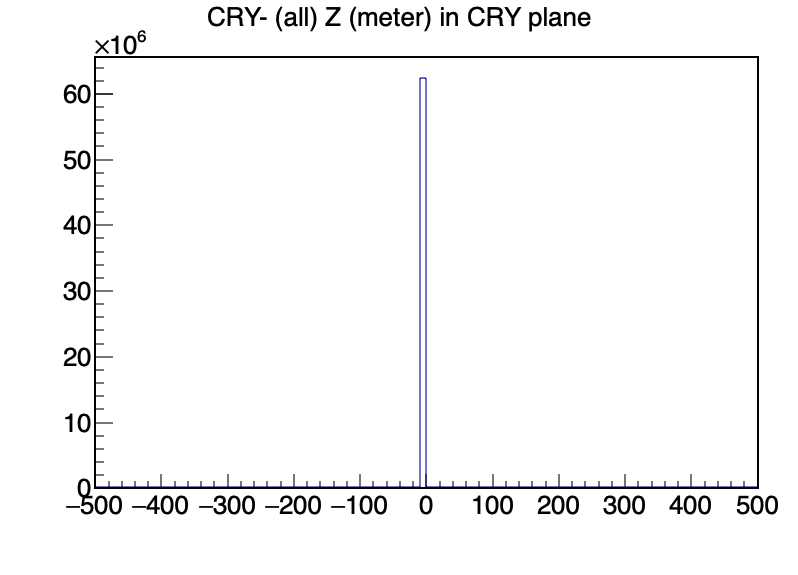

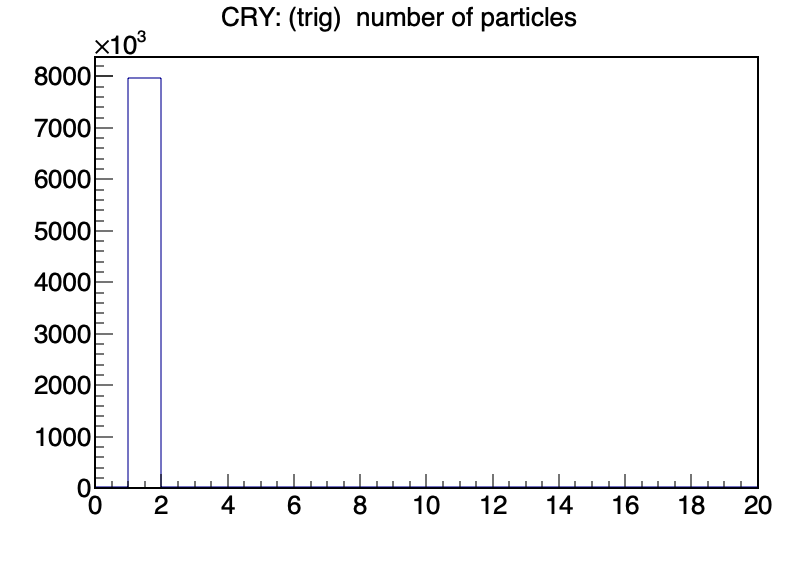

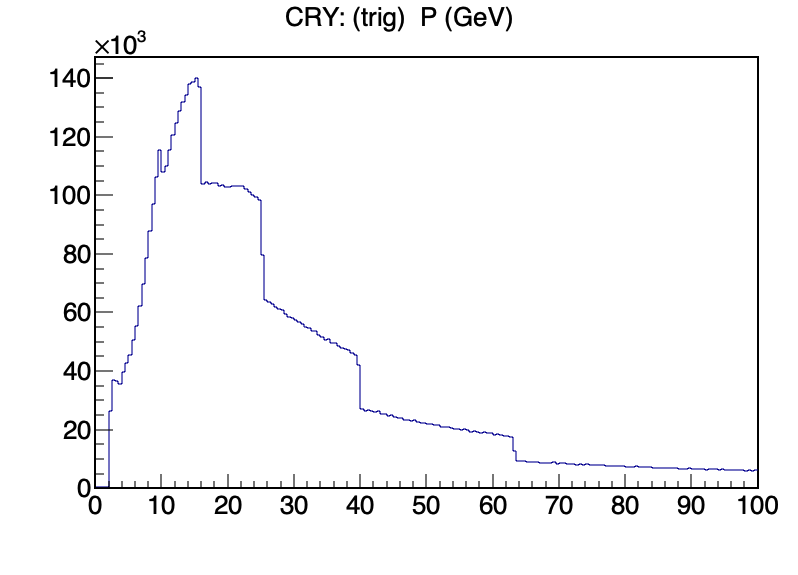

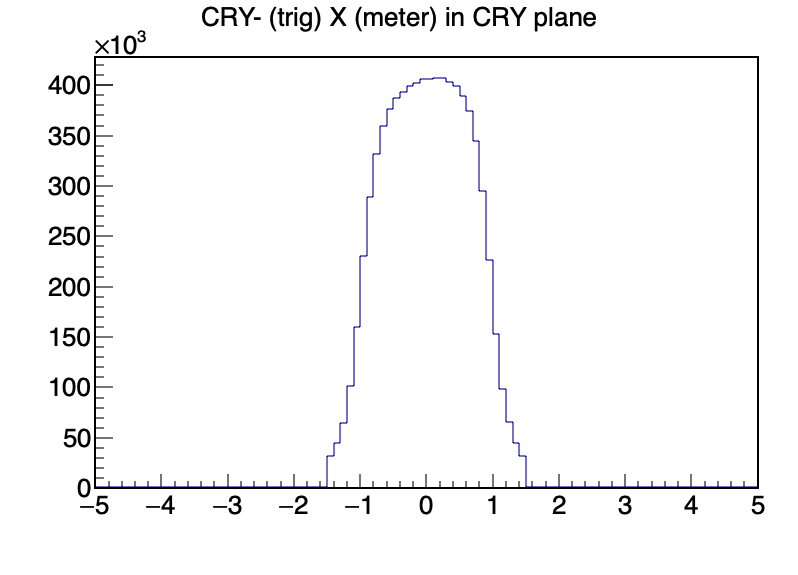

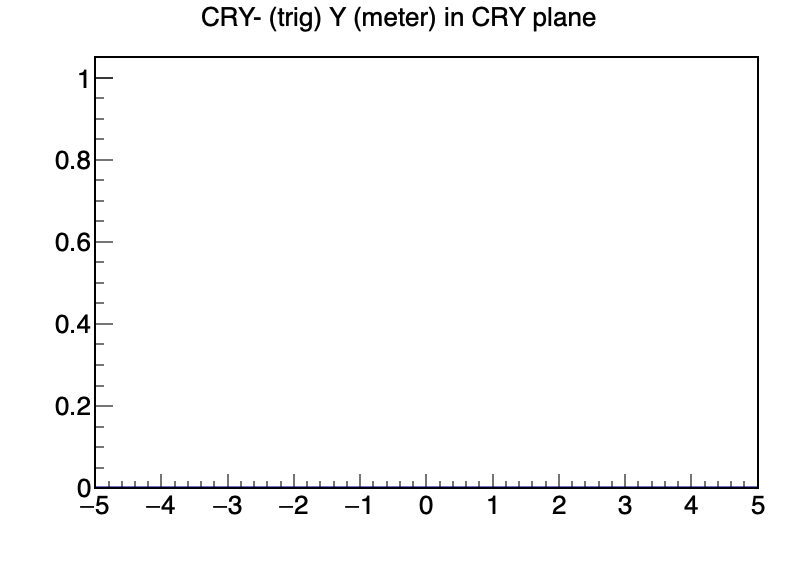

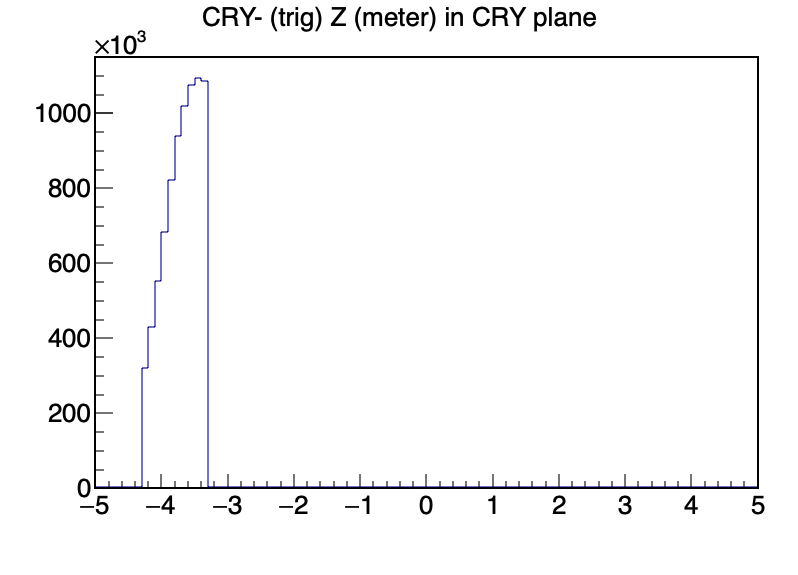

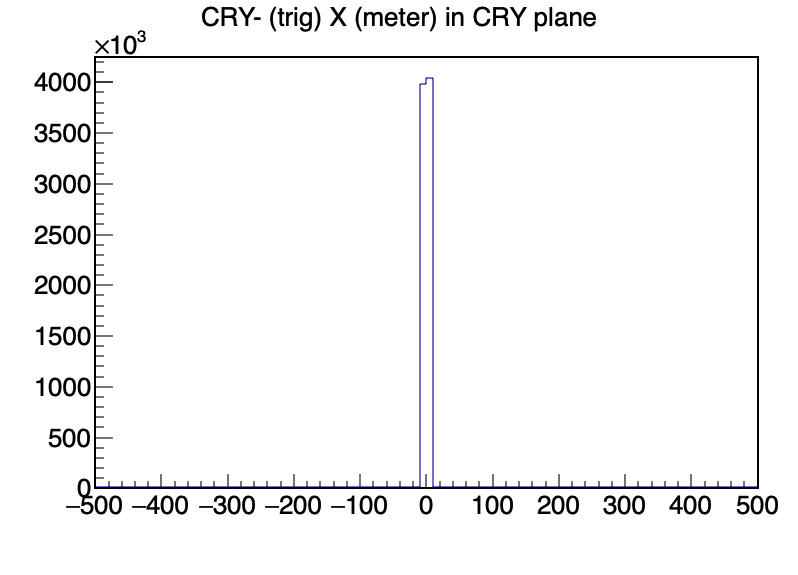

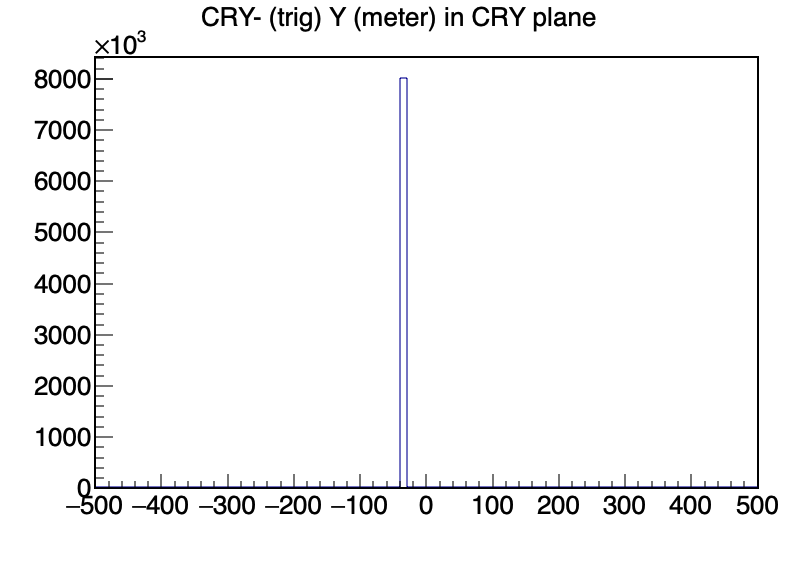

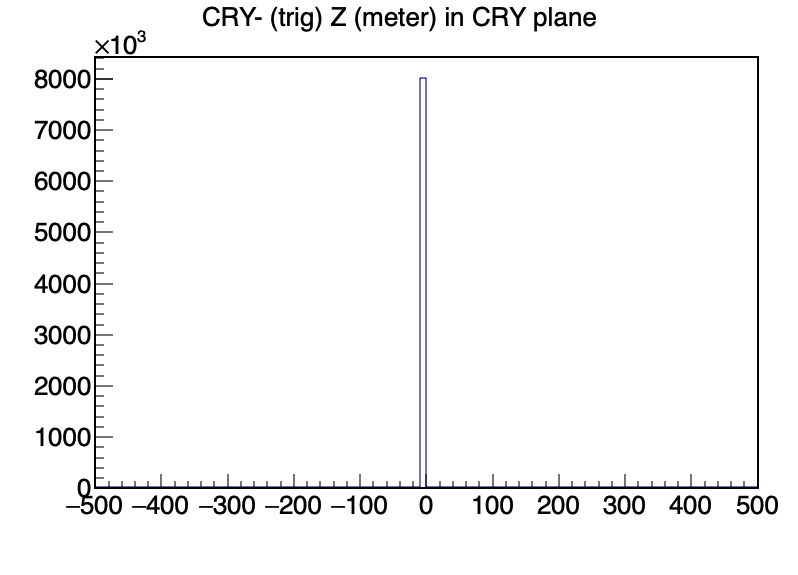

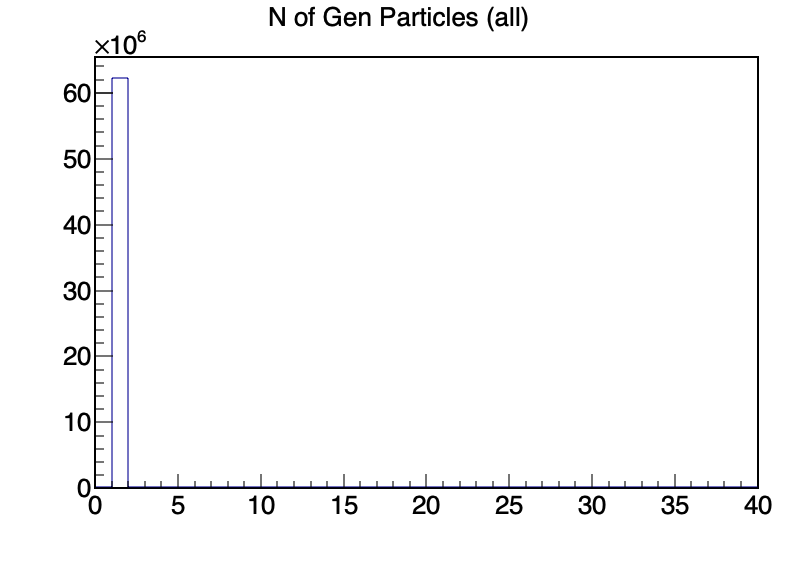

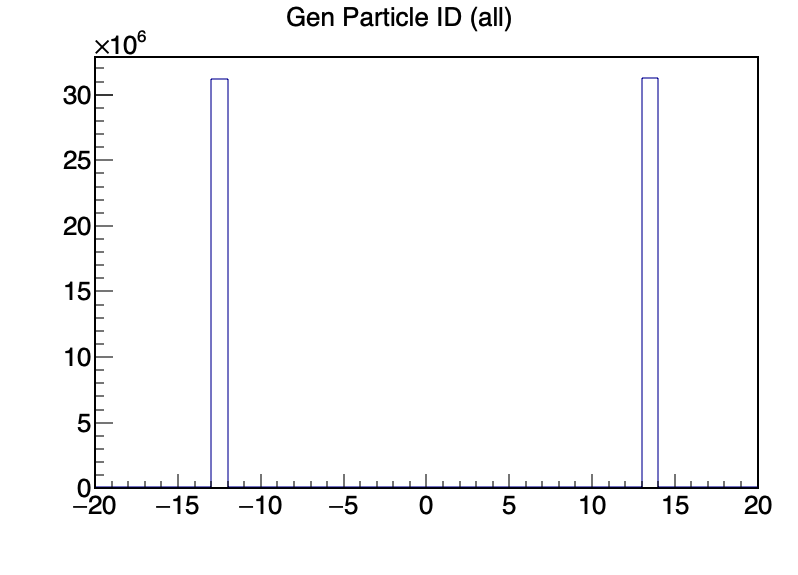

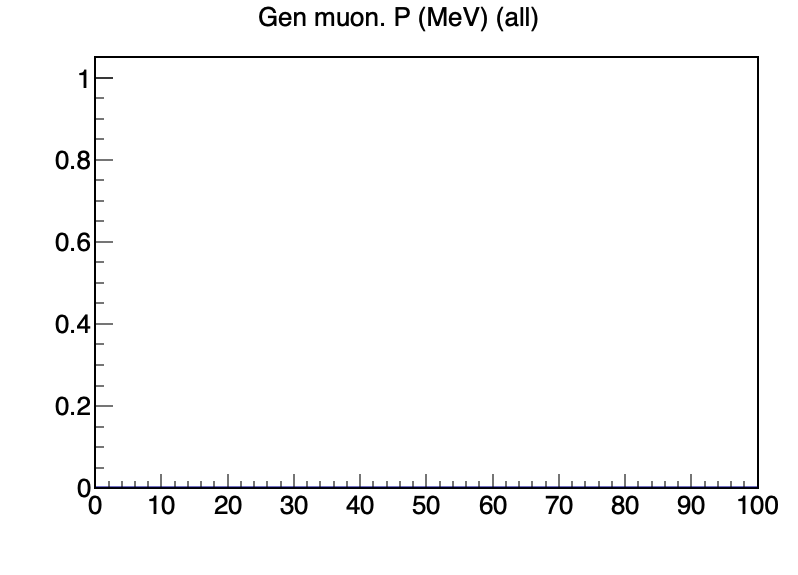

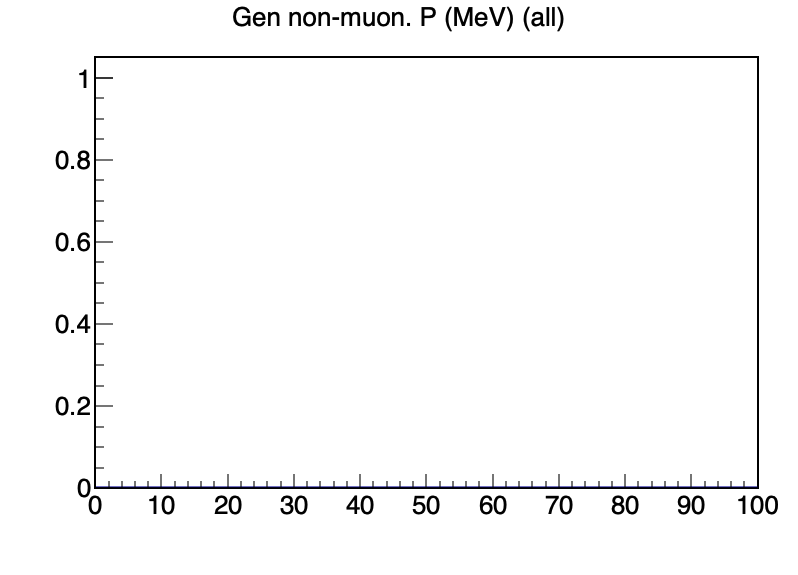

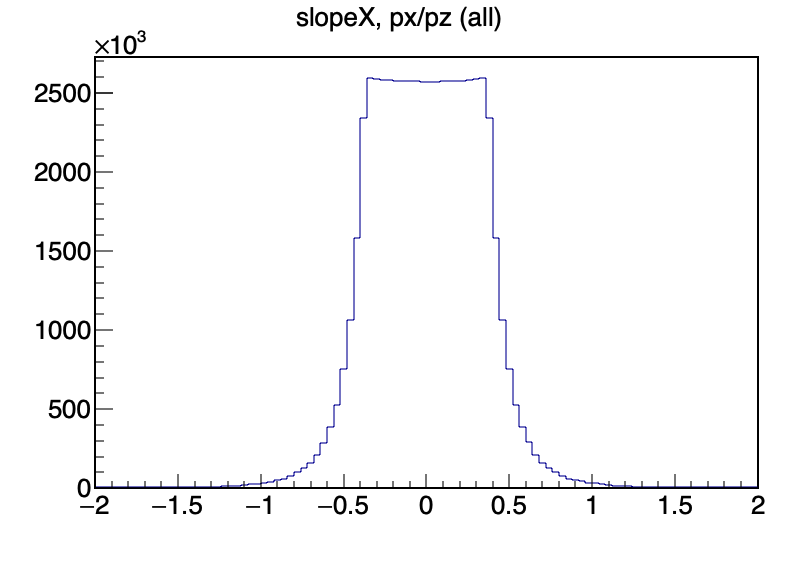

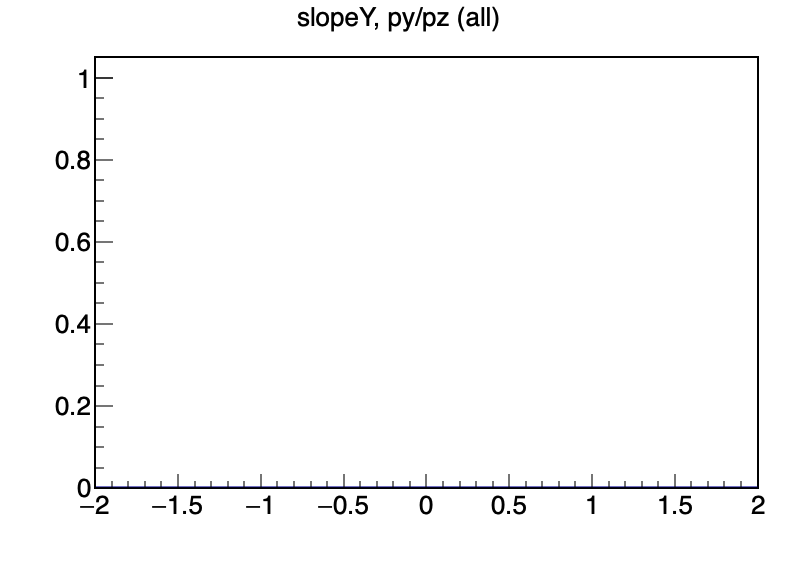

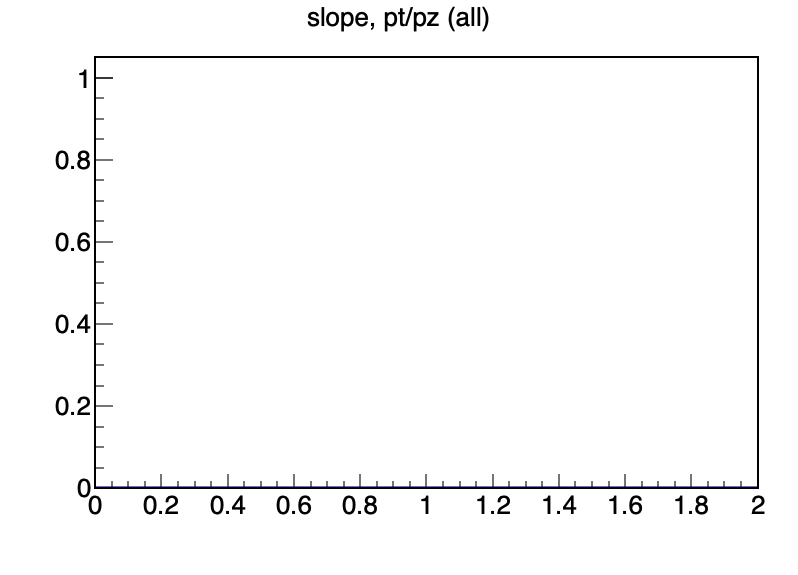

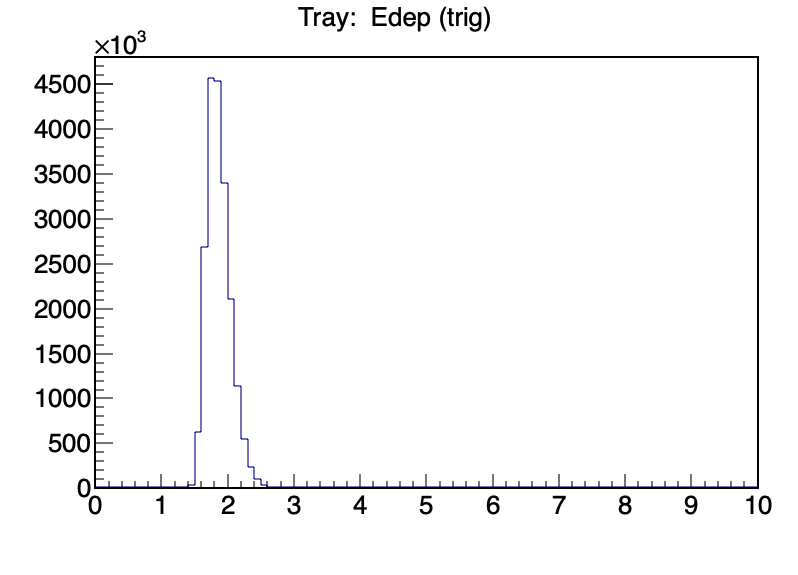

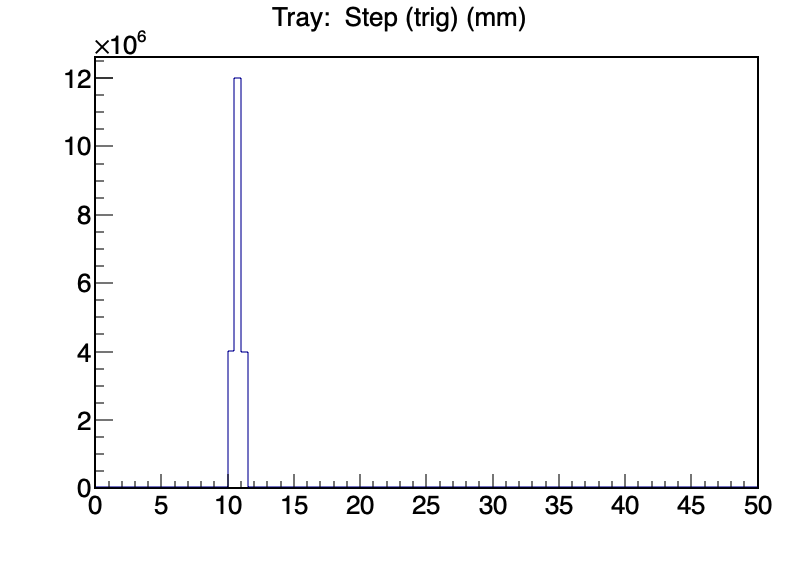

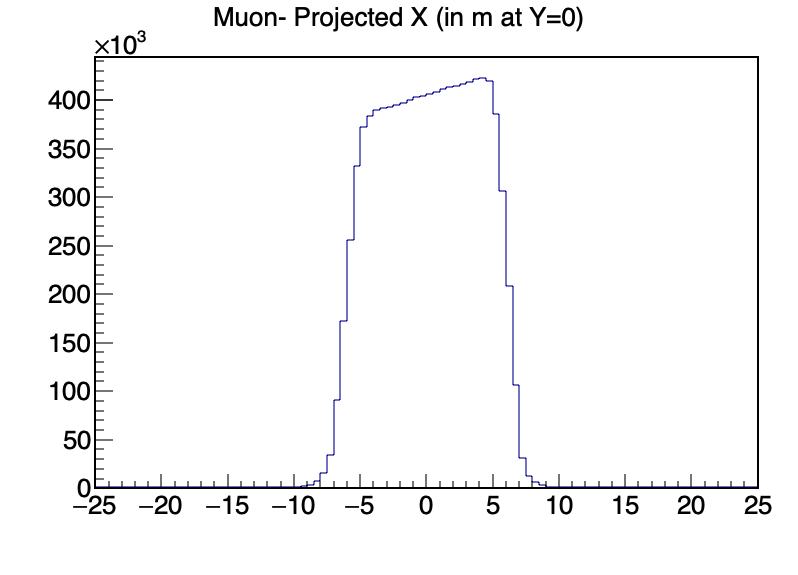

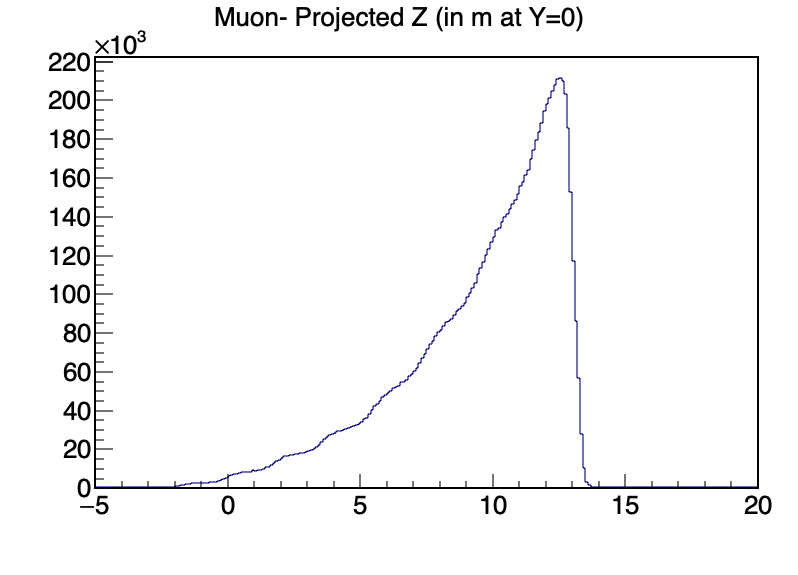

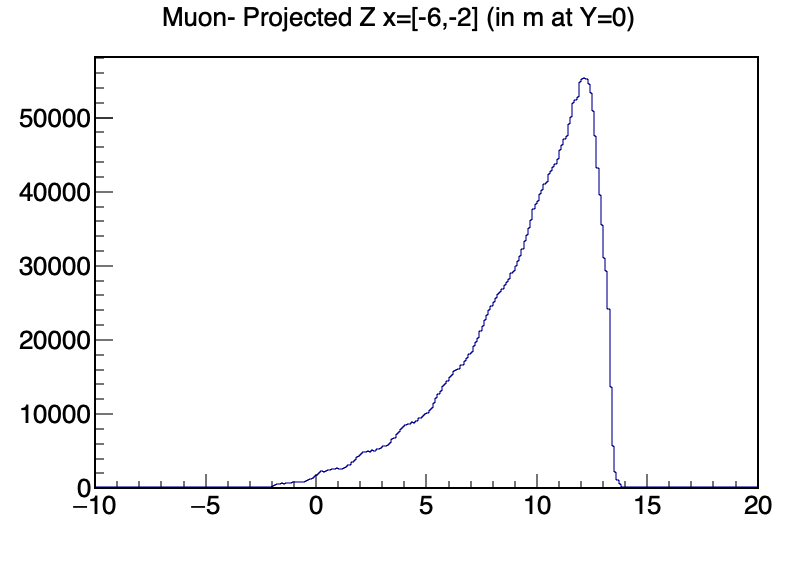

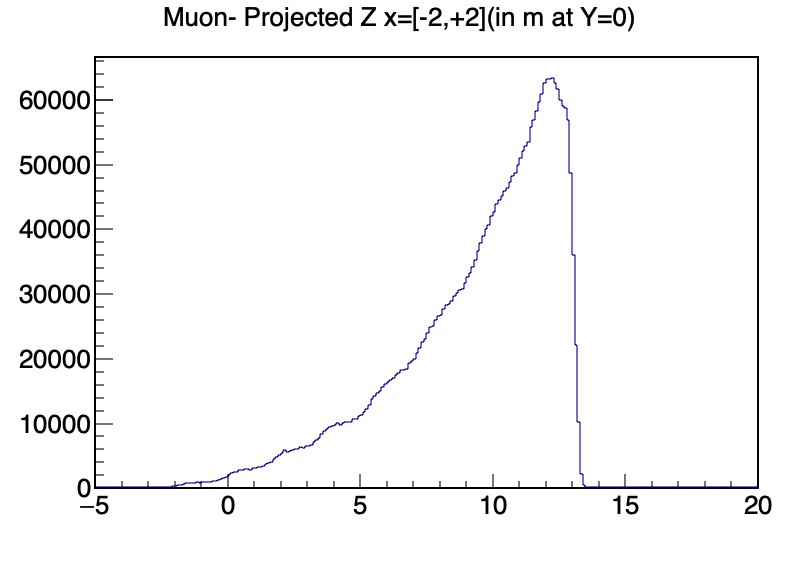

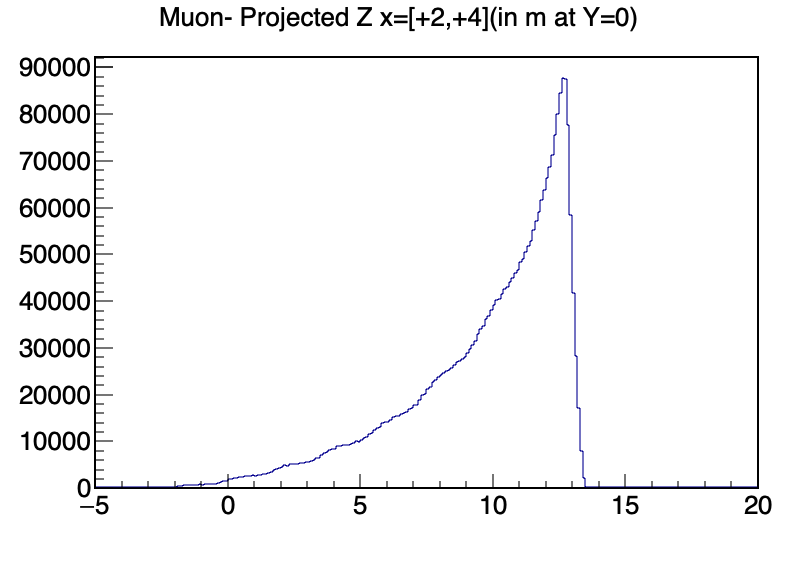

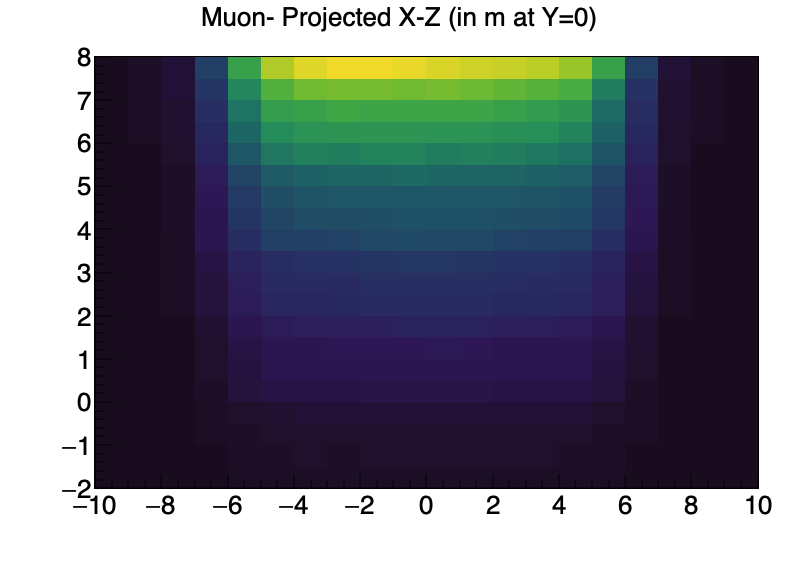

Info in <TCanvas::Print>: file plots/all_CryTime.png has been created
Info in <TCanvas::Print>: file plots/all_nCry.png has been created
Info in <TCanvas::Print>: file plots/all_CryPid.png has been created
Info in <TCanvas::Print>: file plots/all_CryTheta.png has been created
Info in <TCanvas::Print>: file plots/all_CryP.png has been created
Info in <TCanvas::Print>: file plots/all_CryThStr.png has been created
Info in <TCanvas::Print>: file plots/all_CryVx_small.png has been created
Info in <TCanvas::Print>: file plots/all_CryVy_small.png has been created
Info in <TCanvas::Print>: file plots/all_CryVz_small.png has been created
Info in <TCanvas::Print>: file plots/all_CryVx_large.png has been created
Info in <TCanvas::Print>: file plots/all_CryVy_large.png has been created
Info in <TCanvas::Print>: file plots/all_CryVz_large.png has been created
Info in <TCanvas::Print>: file plots/trig_nCry.png has been created
Info in <TCanvas::Print>: file plots/trig_CryP.png has been created
Info 

In [386]:
import ROOT
from IPython.display import Image, display
import os


# Set global font size for axes labels and titles
ROOT.gStyle.SetTitleSize(0.06, "X")  # Title size for X-axis
ROOT.gStyle.SetTitleSize(0.06, "Y")  # Title size for Y-axis
ROOT.gStyle.SetLabelSize(0.05, "X")  # Label size for X-axis
ROOT.gStyle.SetLabelSize(0.05, "Y")  # Label size for Y-axis

ROOT.gStyle.SetPadLeftMargin(0.12)   # Sets left margin for all plots
ROOT.gStyle.SetPadBottomMargin(0.15) # Sets bottom margin for all plots

# ROOT.gStyle.SetPalette(ROOT.kCividis)  # Set the color palette (Colorblind one)
ROOT.gStyle.SetPalette(ROOT.kViridis)  # Set the color palette

# ROOT.gROOT.ForceStyle()  # Ensure the style is applied globally

# Apply the style
# ROOT.gROOT.ForceStyle()

# Open your ROOT file
f = ROOT.TFile("rootfiles/C0RAA_60days.root")


# Loop over all keys in the file
for key in f.GetListOfKeys():
    obj = key.ReadObj()  # retrieve the object
    # Check if the object is a histogram (TH1 or any derived class)
    if obj.InheritsFrom("TH1"):
        # Create a canvas for the histogram
        canvas = ROOT.TCanvas("c_" + obj.GetName(), "Canvas", 800, 600)
        obj.Draw()
        canvas.Update()
        # Define the output directory
        output_dir = "plots"

        # Ensure the directory exists
        os.makedirs(output_dir, exist_ok=True)

        # Save the canvas in the "plots" directory
        image_file = os.path.join(output_dir, obj.GetName() + ".png")
        canvas.SaveAs(image_file)
        # Display the image inline in the notebook
        display(Image(image_file))


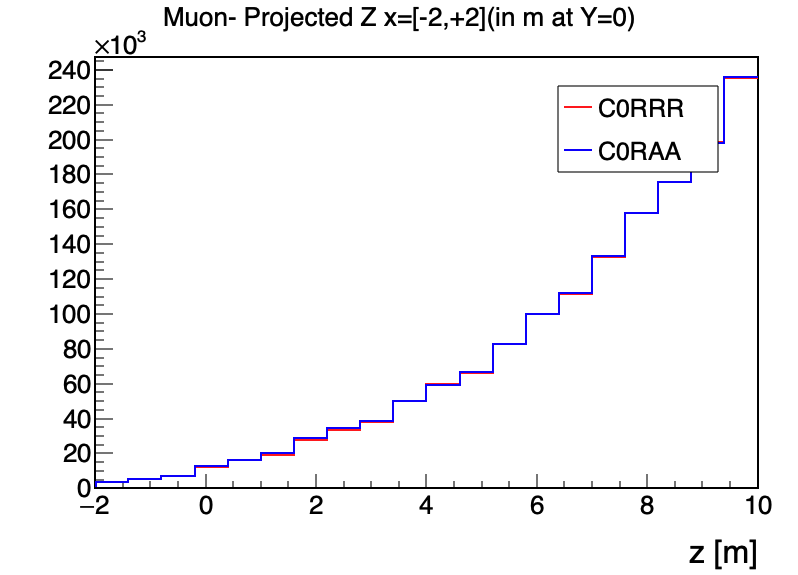

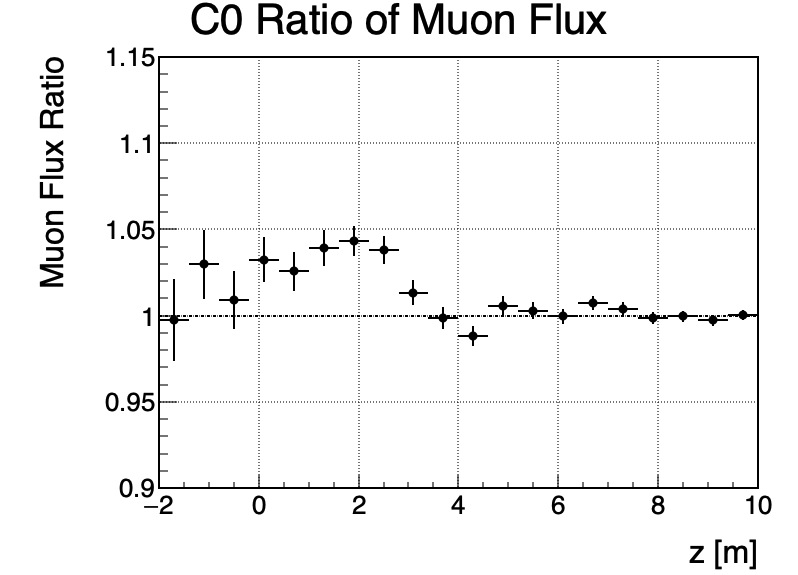

Warning in <TH1D::Rebin>: ngroup=6 is not an exact divider of nbins=250.
Warning in <TH1D::Rebin>: ngroup=6 is not an exact divider of nbins=250.
Info in <TCanvas::Print>: file plots/overlay_histogram.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ratio
Info in <TCanvas::Print>: file plots/ratio_histogram.png has been created


In [387]:
# Open both ROOT files
file1 = ROOT.TFile("rootfiles/C0RRR_120days_2x2x2chamber.root")
file2 = ROOT.TFile("rootfiles/C0RAA_120days_2x2x2chamber.root")

# Retrieve histograms
hist1 = file1.Get("ProjZ2")
hist2 = file2.Get("ProjZ2")

# Define rebin factor (e.g., group bins in sets of 2)
rebin_factor = 6

# Rebin the histograms
hist1_rebinned = hist1.Rebin(rebin_factor)
hist2_rebinned = hist2.Rebin(rebin_factor)


# Check if histograms exist
if not hist1 or not hist2:
    print("One or both histograms not found!")
else:
    # Set x-axis range
    hist1.GetXaxis().SetRangeUser(-2, 10)
    hist2.GetXaxis().SetRangeUser(-2, 10)
    hist1.GetXaxis().SetTitle("z [m]")
    hist2.GetXaxis().SetTitle("z [m]")

    # Reset to auto-scaling for y-axis
    hist1.SetMaximum(-1111)
    hist2.SetMaximum(-1111)

    # Set line colors
    hist1.SetLineColor(ROOT.kRed)   # Red for first histogram
    hist2.SetLineColor(ROOT.kBlue)  # Blue for second histogram
    hist1.SetLineWidth(2)
    hist2.SetLineWidth(2)

    # Create canvas
    canvas = ROOT.TCanvas("c", "Canvas", 800, 600)

    # Draw histograms
    hist1.Draw()       # Draw first histogram
    hist2.Draw("SAME") # Overlay second histogram

    # Add a legend
    legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.85)  # x1, y1, x2, y2
    legend.AddEntry(hist1, "C0RRR", "l")
    legend.AddEntry(hist2, "C0RAA", "l")
    legend.Draw()

    # Update and save
    canvas.Update()
    image_file = "plots/overlay_histogram.png"
    canvas.SaveAs(image_file)

    # Display inline
    display(Image(image_file))

    # Create a ratio histogram (hist2 / hist1)
    ratio_hist = hist2.Clone("ratio_hist")  # Clone hist2 to keep same binning

    ratio_hist.Reset()  # Clear contents before filling manually

    # Loop over bins and compute the ratio + correct errors
    for i in range(1, hist1.GetNbinsX() + 1):  # Bins start at 1 in ROOT
        N_C0RAA = hist2.GetBinContent(i)
        N_C0RRR = hist1.GetBinContent(i)
        
        if N_C0RRR and N_C0RAA > 0:  # Avoid division by zero
            ratio = N_C0RAA / N_C0RRR
            error_C0RAA = ROOT.TMath.Sqrt(N_C0RAA)
            error_C0RRR = ROOT.TMath.Sqrt(N_C0RRR)
            ratio_error = ratio * ROOT.TMath.Sqrt(
                (error_C0RAA / N_C0RAA) ** 2 + (error_C0RRR / N_C0RRR) ** 2
            )
        else:
            ratio = 0
            ratio_error = 0

        # Set bin content and error
        ratio_hist.SetBinContent(i, ratio)
        ratio_hist.SetBinError(i, ratio_error)


    ratio_hist.SetTitle("C0 Ratio of Muon Flux")
    # ratio_hist.Divide(hist1)  # Element-wise division of bins

    # Set line style and axis labels
    ratio_hist.SetLineColor(ROOT.kBlack)  # Black for ratio
    ratio_hist.SetMarkerStyle(20)  # Circle markers
    ratio_hist.SetMarkerSize(1.0)
    ratio_hist.GetYaxis().SetTitle("Muon Flux Ratio")
    # Set global font size for axes labels and titles
    ROOT.gStyle.SetTitleSize(0.06, "X")  # Title size for X-axis
    ROOT.gStyle.SetTitleSize(0.06, "Y")  # Title size for Y-axis
    ROOT.gStyle.SetLabelSize(0.05, "X")  # Label size for X-axis
    ROOT.gStyle.SetLabelSize(0.05, "Y")  # Label size for Y-axis
    ROOT.gStyle.SetPadLeftMargin(0.2)   # Sets left margin for all plots
    ROOT.gStyle.SetPadRightMargin(0.05)   # Sets left margin for all plots
    ROOT.gStyle.SetPadBottomMargin(0.15) # Sets bottom margin for all plots
    ratio_hist.GetXaxis().SetTitle(hist1.GetXaxis().GetTitle())


    # Set y-axis range (optional)
    ratio_hist.SetMinimum(0.9)  # Adjust as needed
    ratio_hist.SetMaximum(1.15)

    # Create canvas
    canvas_ratio = ROOT.TCanvas("c_ratio", "Ratio Canvas", 800, 600)

    # Draw ratio histogram
    ratio_hist.SetStats(False)  # Disable stats box for this histogram only
    ratio_hist.Draw("E")  # "E" draws error bars

    # Now modify the title appearance
    canvas_ratio.Update()  # Necessary to create the title TPaveText
    title = canvas_ratio.GetPrimitive("title")
    if title:
        title.SetTextSize(0.08)  # Adjust to your liking
        title.SetTextFont(42)    # Optional: clean sans-serif font
        canvas_ratio.Modified()
        canvas_ratio.Update()

    # Create a horizontal line at y = 1
    line = ROOT.TLine(-2, 1, 10, 1)
    line.SetLineColor(ROOT.kBlack)
    line.SetLineStyle(2)  # Dashed line
    line.SetLineWidth(2)
    line.Draw("SAME")  # Draw on the same canvas

    # Update and save
    canvas_ratio.SetGrid()
    canvas_ratio.Update()
    ratio_image_file = "plots/ratio_histogram.png"
    canvas_ratio.SaveAs(ratio_image_file)

    # Display inline
    display(Image(ratio_image_file))


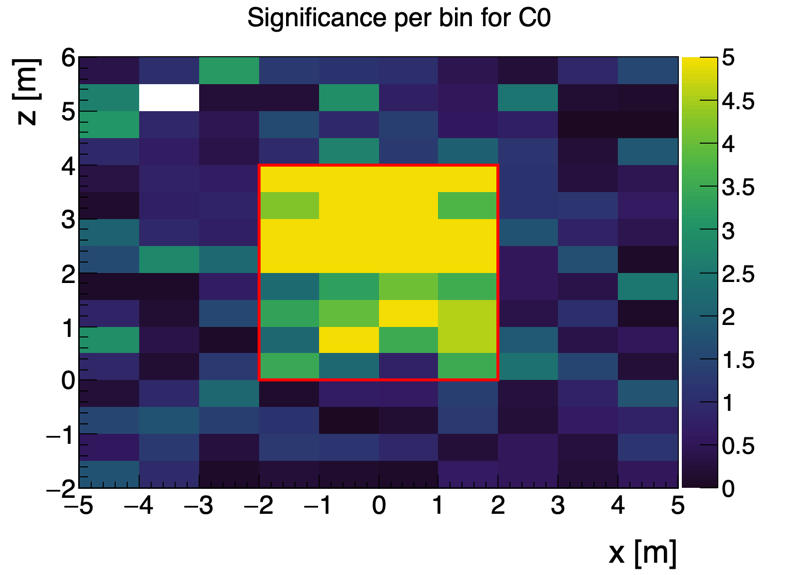

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_significance
Info in <TCanvas::Print>: file plots/significance_2D_histogram.png has been created


In [400]:
import ROOT
import numpy as np
from IPython.display import Image, display

# Open both ROOT files
file1 = ROOT.TFile("rootfiles/C0RRR_120days.root")
file2 = ROOT.TFile("rootfiles/C0RAA_120days.root")

# Retrieve 2D histograms
hist2D_1 = file1.Get("ProjXZ")  # C0RRR
hist2D_2 = file2.Get("ProjXZ")  # C0RAA

# Check if histograms exist
if not hist2D_1 or not hist2D_2:
    print("One or both 2D histograms not found!")
else:
    # Clone one to create the output significance histogram
    significance_hist = hist2D_1.Clone("significance_hist")
    significance_hist.Reset()

    # Loop over all bins
    for i in range(1, hist2D_1.GetNbinsX() + 1):
        for j in range(1, hist2D_1.GetNbinsY() + 1):
            rrr = hist2D_1.GetBinContent(i, j)
            raa = hist2D_2.GetBinContent(i, j)

            if rrr > 0 and raa > 0:
                r = raa / rrr
                r_err = r * np.sqrt(1/raa + 1/rrr)
                significance = np.abs((1 - r) / r_err) if r_err != 0 else 0
            else:
                significance = 0  # or float('nan') to mask

            significance_hist.SetBinContent(i, j, significance)

    # Create canvas
    canvas_significance = ROOT.TCanvas("c_significance", "2D Significance Canvas", 800, 600)

    # Adjust Z-axis range if needed
    significance_hist.SetMinimum(0)
    significance_hist.SetMaximum(5)

    # Axis and titles
    significance_hist.GetXaxis().SetRangeUser(-5, 5)
    significance_hist.GetYaxis().SetRangeUser(-2, 6)
    significance_hist.GetYaxis().SetTitleOffset(0.7)
    significance_hist.GetXaxis().SetTitle("x [m]")
    significance_hist.GetYaxis().SetTitle("z [m]")
    significance_hist.SetTitle("Significance per bin for C0")

    ROOT.gStyle.SetPadLeftMargin(0.1)
    ROOT.gStyle.SetPadRightMargin(0.15)
    ROOT.gStyle.SetPadBottomMargin(0.15)

    significance_hist.Draw("COLZ")
    significance_hist.SetStats(False)

    # Optional box
    box = ROOT.TBox(-2, 0, 2, 4)
    box.SetFillStyle(0)
    box.SetLineColor(ROOT.kRed)
    box.SetLineWidth(3)
    box.Draw("same")


    # Save and display
    canvas_significance.Update()
    significance_file = "plots/significance_2D_histogram.png"
    canvas_significance.SaveAs(significance_file)
    display(Image(significance_file))


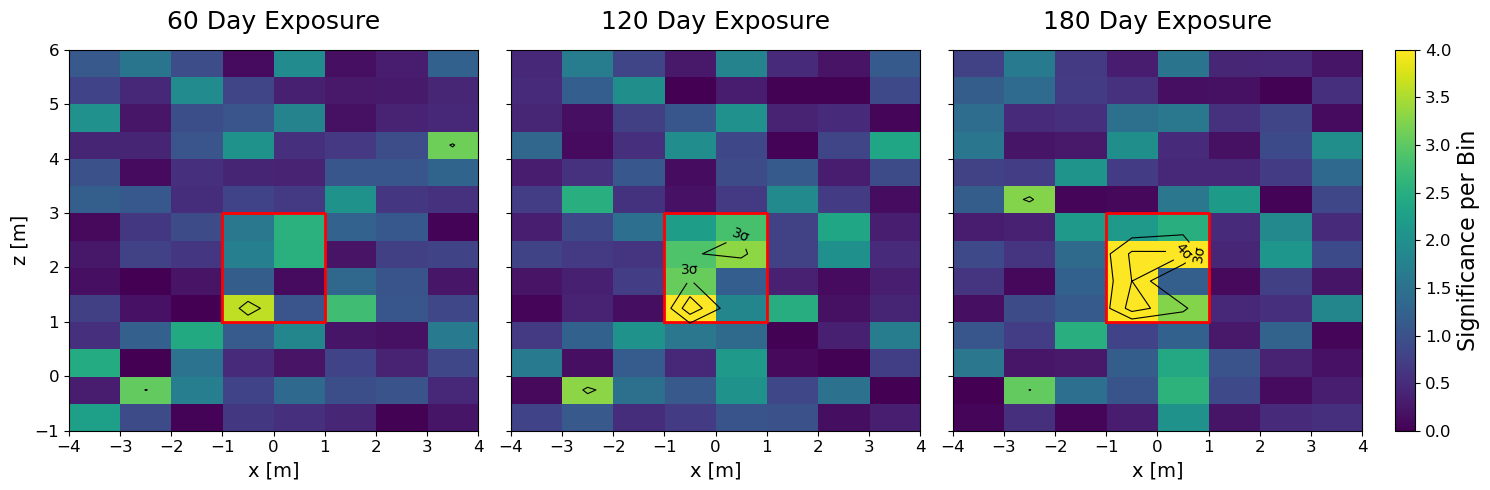

In [433]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Function to extract 2D histograms from ROOT files
def extract_histogram(rootfile, histname):
    with uproot.open(rootfile) as f:
        hist = f[histname]
        values = hist.values()  # 2D NumPy array of bin contents
        edges_x = hist.axis(0).edges()  # X bin edges
        edges_y = hist.axis(1).edges()  # Y bin edges
    return values, edges_x, edges_y

# ROOT files and histogram name
root_files = [
    "rootfiles/C0RAA_60days_2x2x2chamber.root",
    "rootfiles/C0RAA_120days_2x2x2chamber.root",
    "rootfiles/C0RAA_180days_2x2x2chamber.root"
]
reference_files = [
    "rootfiles/C0RRR_60days_2x2x2chamber.root",
    "rootfiles/C0RRR_120days_2x2x2chamber.root",
    "rootfiles/C0RRR_180days_2x2x2chamber.root"
]
hist_name = "ProjXZ"

# Extract histograms and compute significance
histograms = []
for data_file, ref_file in zip(root_files, reference_files):
    values_data, x_edges, y_edges = extract_histogram(data_file, hist_name)
    values_ref, _, _ = extract_histogram(ref_file, hist_name)

    # Avoid division by zero
    mask = (values_data > 0) & (values_ref > 0)

    r = np.zeros_like(values_data)
    r_err = np.ones_like(values_data)  # prevent div by 0
    significance = np.zeros_like(values_data)

    r[mask] = values_data[mask] / values_ref[mask]
    r_err[mask] = r[mask] * np.sqrt(1 / values_data[mask] + 1 / values_ref[mask])
    significance[mask] = np.abs((1 - r[mask]) / r_err[mask])

    histograms.append(significance)

# Setup Matplotlib figure
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05])  # Last column for colorbar

# Plot each 2D histogram
titles = ["60 Day Exposure", "120 Day Exposure", "180 Day Exposure"]
vmin, vmax = 0, 4  # Typical range for significance

x_min, x_max = -4, 4
y_min, y_max = -1, 6

for i in range(3):
    ax = plt.subplot(gs[i])
    img = ax.imshow(histograms[i].T, origin="lower", aspect="auto",
                    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                    vmin=vmin, vmax=vmax, cmap="viridis")
    
    # Set title with fontsize=18 and pad=15
    ax.set_title(titles[i], fontsize=18, pad=15)
    
    # Set axis labels with fontsize=14
    ax.set_xlabel("x [m]", fontsize=14)
    if i == 0:
        ax.set_ylabel("z [m]", fontsize=14)
    else:
        ax.set_yticklabels([], fontsize=14)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Draw red box
    ax.plot([-1, 1, 1, -1, -1], [1, 1, 3, 3, 1], color="red", linewidth=2)
    
    # Set tick labels size to 12
    ax.tick_params(axis='both', labelsize=12)

    # Define contour levels (e.g., ±1σ, ±2σ, ±3σ)
    contour_levels = [3, 4, 6]

    # Plot contour lines over the heatmap
    X, Y = np.meshgrid(x_edges, y_edges)
    cs = ax.contour(X[:-1, :-1] + np.diff(x_edges)/2.0,
                    Y[:-1, :-1] + np.diff(y_edges)/2.0,
                    histograms[i].T,
                    levels=contour_levels,
                    colors='black',
                    linewidths=0.8)

    # Label contour lines with fontsize=10
    ax.clabel(cs, fmt='%dσ', fontsize=10)

# Add single colorbar
cbar_ax = plt.subplot(gs[3])
cbar = plt.colorbar(img, cax=cbar_ax)
cbar.set_label("Significance per Bin", fontsize=16)
cbar.ax.tick_params(labelsize=12)

# Layout and save
plt.tight_layout()
plt.savefig("plots/muon_flux_significance.png", dpi=300)
plt.show()


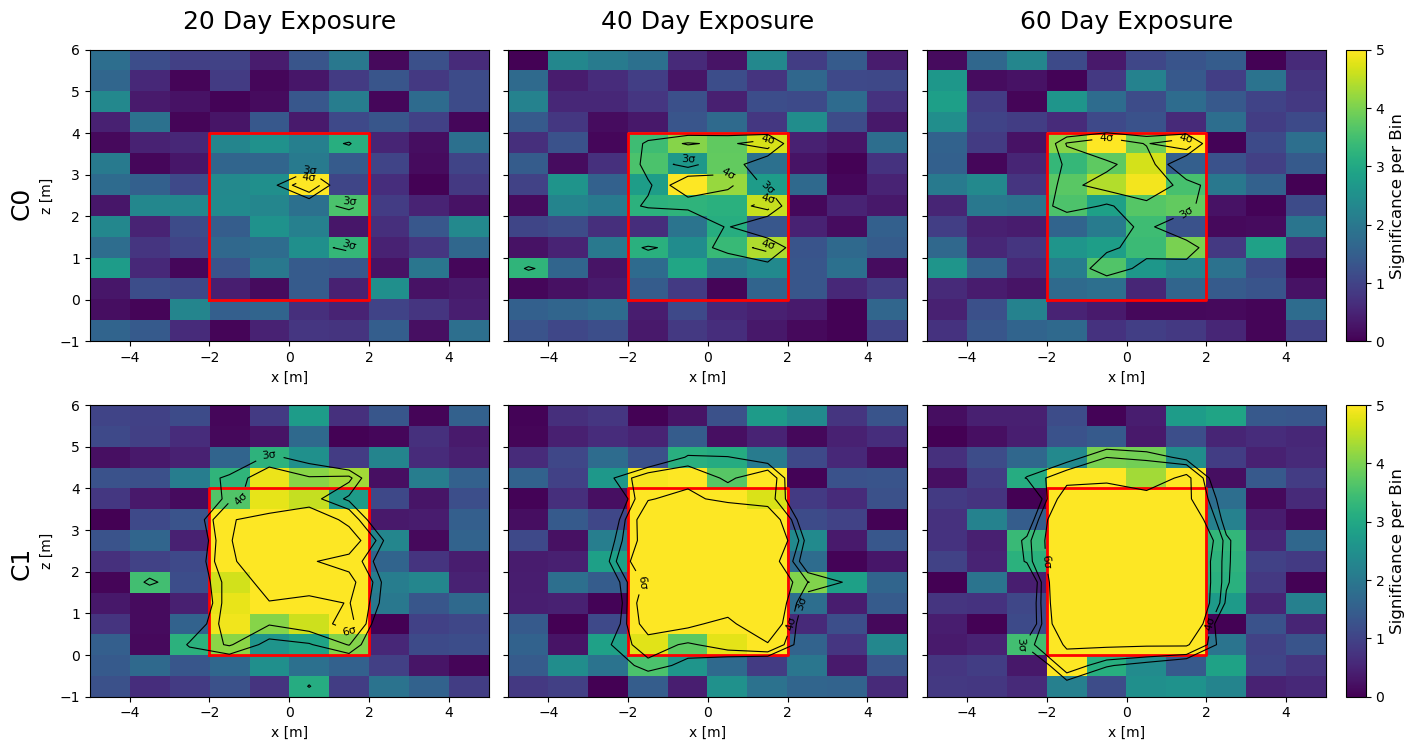

In [403]:
# --- Prepare your two rows of ROOT files ---
root_files_c0 = [
    "rootfiles/C0RAA_20days.root",
    "rootfiles/C0RAA_40days.root",
    "rootfiles/C0RAA_60days.root",
]
ref_files_c0 = [
    "rootfiles/C0RRR_20days.root",
    "rootfiles/C0RRR_40days.root",
    "rootfiles/C0RRR_60days.root",
]

root_files_c3 = [
    "rootfiles/C3RAA_20days.root",
    "rootfiles/C3RAA_40days.root",
    "rootfiles/C3RAA_60days.root"
]
ref_files_c3 = [
    "rootfiles/C3RRR_20days.root",
    "rootfiles/C3RRR_40days.root",
    "rootfiles/C3RRR_60days.root"
]

all_root_files = [root_files_c0, root_files_c3]
all_ref_files = [ref_files_c0, ref_files_c3]
row_labels = ["C0", "C1"]

# --- Setup figure with 2 rows, 3 columns + 1 colorbar column ---
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 0.05])  # 3 plots + colorbar

titles = ["20 Day Exposure", "40 Day Exposure", "60 Day Exposure"]
vmin, vmax = 0, 5
x_min, x_max = -5, 5
y_min, y_max = -1, 6

img_top = None
img_bottom = None


# --- Loop through rows (C0, C3) and columns (20, 40, 60 days) ---
for row in range(2):
    histograms = []
    for data_file, ref_file in zip(all_root_files[row], all_ref_files[row]):
        values_data, x_edges, y_edges = extract_histogram(data_file, hist_name)
        values_ref, _, _ = extract_histogram(ref_file, hist_name)

        mask = (values_data > 0) & (values_ref > 0)

        r = np.zeros_like(values_data)
        r_err = np.ones_like(values_data)
        significance = np.zeros_like(values_data)

        r[mask] = values_data[mask] / values_ref[mask]
        r_err[mask] = r[mask] * np.sqrt(1 / values_data[mask] + 1 / values_ref[mask])
        significance[mask] = np.abs((1 - r[mask]) / r_err[mask])

        histograms.append(significance)

    for col in range(3):
        ax = plt.subplot(gs[row, col])
        img = ax.imshow(histograms[col].T, origin="lower", aspect="auto",
                        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                        vmin=vmin, vmax=vmax, cmap="viridis")
        if row == 0 and col == 0:
            img_top = img
        elif row == 1 and col == 0:
            img_bottom = img
        if row == 0:
            ax.set_title(titles[col], fontsize=18, pad = 15)
        ax.set_xlabel("x [m]")
        if col == 0:
            ax.set_ylabel("z [m]")
        else:
            ax.set_yticklabels([])

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.plot([-2, 2, 2, -2, -2], [0, 0, 4, 4, 0], color="red", linewidth=2)

        contour_levels = [3, 4, 6]
        X, Y = np.meshgrid(x_edges, y_edges)
        cs = ax.contour(X[:-1, :-1] + np.diff(x_edges)/2.0,
                        Y[:-1, :-1] + np.diff(y_edges)/2.0,
                        histograms[col].T,
                        levels=contour_levels,
                        colors='black',
                        linewidths=0.8)
        ax.clabel(cs, fmt='%dσ', fontsize=8)

    # Add big row label (e.g., "C0", "C1") on the left side
    fig.text(0.04, 0.74 - row * 0.45, row_labels[row], fontsize=18, va='center', rotation='vertical')

# --- Add separate colorbars for top and bottom rows ---
# Colorbar for top row (C0)
cbar_ax_top = plt.subplot(gs[0, 3])
cbar_top = plt.colorbar(img_top, cax=cbar_ax_top)
cbar_top.set_label("Significance per Bin", fontsize=14)

# Colorbar for bottom row (C1)
cbar_ax_bottom = plt.subplot(gs[1, 3])
cbar_bottom = plt.colorbar(img_bottom, cax=cbar_ax_bottom)
cbar_bottom.set_label("Significance per Bin", fontsize=14)



plt.tight_layout(rect=[0.05, 0.05, 0.98, 1])  # leave space for row labels and colorbars
plt.savefig("plots/muon_flux_significance_grid.png", dpi=300)
plt.show()


## With 4 files

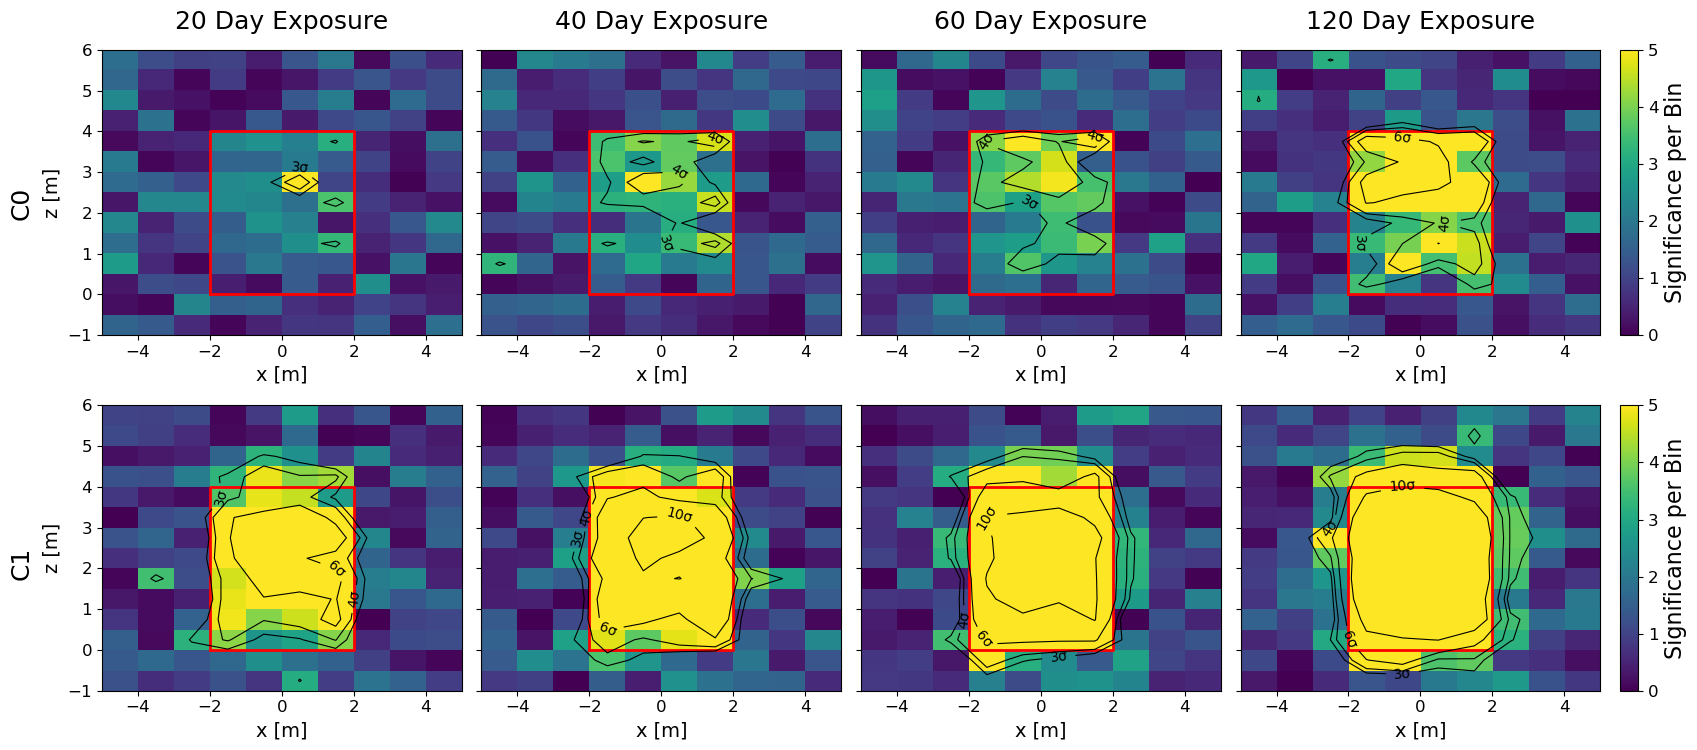

In [427]:
from matplotlib.colors import LogNorm


# --- Prepare your two rows of ROOT files ---
root_files_c0 = [
    "rootfiles/C0RAA_20days.root",
    "rootfiles/C0RAA_40days.root",
    "rootfiles/C0RAA_60days.root",
    "rootfiles/C0RAA_120days.root",  # New file
]
ref_files_c0 = [
    "rootfiles/C0RRR_20days.root",
    "rootfiles/C0RRR_40days.root",
    "rootfiles/C0RRR_60days.root",
    "rootfiles/C0RRR_120days.root",  # New file
]

root_files_c3 = [
    "rootfiles/C3RAA_20days.root",
    "rootfiles/C3RAA_40days.root",
    "rootfiles/C3RAA_60days.root",
    "rootfiles/C3RAA_120days.root",  # New file
]
ref_files_c3 = [
    "rootfiles/C3RRR_20days.root",
    "rootfiles/C3RRR_40days.root",
    "rootfiles/C3RRR_60days.root",
    "rootfiles/C3RRR_120days.root",  # New file
]

all_root_files = [root_files_c0, root_files_c3]
all_ref_files = [ref_files_c0, ref_files_c3]
row_labels = ["C0", "C1"]

# --- Setup figure with 2 rows, 4 columns + 1 colorbar column ---
fig = plt.figure(figsize=(18, 8))  # wider figure
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 0.05])  # 4 plots + colorbar

titles = ["20 Day Exposure", "40 Day Exposure", "60 Day Exposure", "120 Day Exposure"]
vmin, vmax = 0, 5
x_min, x_max = -5, 5
y_min, y_max = -1, 6

img_top = None
img_bottom = None

# --- Loop through rows (C0, C3) and columns (20, 40, 60, 120 days) ---
for row in range(2):
    histograms = []
    for data_file, ref_file in zip(all_root_files[row], all_ref_files[row]):
        values_data, x_edges, y_edges = extract_histogram(data_file, hist_name)
        values_ref, _, _ = extract_histogram(ref_file, hist_name)

        mask = (values_data > 0) & (values_ref > 0)

        r = np.zeros_like(values_data)
        r_err = np.ones_like(values_data)
        significance = np.zeros_like(values_data)

        r[mask] = values_data[mask] / values_ref[mask]
        r_err[mask] = r[mask] * np.sqrt(1 / values_data[mask] + 1 / values_ref[mask])
        significance[mask] = np.abs((1 - r[mask]) / r_err[mask])

        histograms.append(significance)

    for col in range(4):  # now loop over 4 columns
        ax = plt.subplot(gs[row, col])
        img = ax.imshow(histograms[col].T, origin="lower", aspect="auto",
                        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                        vmin=vmin, vmax=vmax, cmap="viridis")

        if row == 0 and col == 0:
            img_top = img
        elif row == 1 and col == 0:
            img_bottom = img
        if row == 0:
            ax.set_title(titles[col], fontsize=18, pad=15)
        ax.set_xlabel("x [m]", fontsize = 14)
        if col == 0:
            ax.set_ylabel("z [m]", fontsize = 14)
        else:
            ax.set_yticklabels([], fontsize = 14)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.plot([-2, 2, 2, -2, -2], [0, 0, 4, 4, 0], color="red", linewidth=2)
        ax.tick_params(axis='both', labelsize=12)


        contour_levels = [3, 4, 6, 10]
        X, Y = np.meshgrid(x_edges, y_edges)
        cs = ax.contour(X[:-1, :-1] + np.diff(x_edges)/2.0,
                        Y[:-1, :-1] + np.diff(y_edges)/2.0,
                        histograms[col].T,
                        levels=contour_levels,
                        colors='black',
                        linewidths=0.8)
        ax.clabel(cs, fmt='%dσ', fontsize=10)
        

    fig.text(0.04, 0.74 - row * 0.45, row_labels[row], fontsize=18, va='center', rotation='vertical')

# --- Add colorbars for top and bottom rows ---
cbar_ax_top = plt.subplot(gs[0, 4])
cbar_top = plt.colorbar(img_top, cax=cbar_ax_top)
cbar_top.set_label("Significance per Bin", fontsize=16)
cbar_top.ax.tick_params(labelsize=12)


cbar_ax_bottom = plt.subplot(gs[1, 4])
cbar_bottom = plt.colorbar(img_bottom, cax=cbar_ax_bottom)
cbar_bottom.set_label("Significance per Bin", fontsize=16)
cbar_bottom.ax.tick_params(labelsize=12)


plt.tight_layout(rect=[0.05, 0.05, 0.98, 1])
plt.savefig("plots/muon_flux_significance_grid_4x2.png", dpi=300)
plt.show()
